In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
import boto3
# Create the Bedrock client
client = boto3.client(
    service_name="bedrock-runtime",
    region_name="us-east-2"
)

In [6]:
# Define the model and message
model_id = "us.amazon.nova-lite-v1:0"
messages = [{"role": "user", "content": [{"text": "What is context engineering?"}]}]

In [7]:
# Make the API call
response = client.converse(
    modelId=model_id,
    messages=messages,
)

In [8]:
response

{'ResponseMetadata': {'RequestId': '78cf6446-91b7-4dc2-ac03-702e95c98603',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'date': 'Fri, 08 Aug 2025 18:30:15 GMT',
   'content-type': 'application/json',
   'content-length': '3691',
   'connection': 'keep-alive',
   'x-amzn-requestid': '78cf6446-91b7-4dc2-ac03-702e95c98603'},
  'RetryAttempts': 0},
 'output': {'message': {'role': 'assistant',
   'content': [{'text': "Context engineering is a multidisciplinary approach that focuses on understanding and designing systems, applications, and environments that are sensitive to the context in which they are used. This involves analyzing and leveraging various contextual factors to enhance user experience, improve system performance, and enable more effective interactions.\n\n### Key Components of Context Engineering:\n\n1. **Context Awareness**:\n   - The ability of a system to perceive and interpret its environment, including user preferences, location, time, social interactions, and other releva

In [11]:
response['output']['message']['content'][0]['text']

"Context engineering is a multidisciplinary approach that focuses on understanding and designing systems, applications, and environments that are sensitive to the context in which they are used. This involves analyzing and leveraging various contextual factors to enhance user experience, improve system performance, and enable more effective interactions.\n\n### Key Components of Context Engineering:\n\n1. **Context Awareness**:\n   - The ability of a system to perceive and interpret its environment, including user preferences, location, time, social interactions, and other relevant factors.\n\n2. **Context Acquisition**:\n   - Gathering data from various sources such as sensors, user inputs, and external data providers. This can include information like GPS data, user behavior, and environmental conditions.\n\n3. **Context Representation**:\n   - Structuring and modeling the acquired context data in a way that makes it usable for decision-making processes. This often involves creating 

In [12]:
from IPython.display import display, Markdown

Markdown(response['output']['message']['content'][0]['text'])

Context engineering is a multidisciplinary approach that focuses on understanding and designing systems, applications, and environments that are sensitive to the context in which they are used. This involves analyzing and leveraging various contextual factors to enhance user experience, improve system performance, and enable more effective interactions.

### Key Components of Context Engineering:

1. **Context Awareness**:
   - The ability of a system to perceive and interpret its environment, including user preferences, location, time, social interactions, and other relevant factors.

2. **Context Acquisition**:
   - Gathering data from various sources such as sensors, user inputs, and external data providers. This can include information like GPS data, user behavior, and environmental conditions.

3. **Context Representation**:
   - Structuring and modeling the acquired context data in a way that makes it usable for decision-making processes. This often involves creating ontologies or schemas that define the relationships between different context elements.

4. **Context Reasoning**:
   - Applying logic and algorithms to interpret the context data and derive meaningful insights. This can involve machine learning techniques to predict user behavior or environmental changes.

5. **Context Adaptation**:
   - Adjusting the system's behavior or interface based on the interpreted context. This can mean changing the layout of a mobile app based on the user's location or providing personalized recommendations based on user history.

### Applications of Context Engineering:

1. **Smart Homes**:
   - Systems that adjust lighting, temperature, and security based on the presence and activities of the inhabitants.

2. **Mobile Applications**:
   - Apps that offer personalized content or services based on the user's location, time of day, and previous interactions.

3. **Healthcare**:
   - Wearable devices and health monitoring systems that provide context-aware alerts and recommendations based on real-time health data.

4. **Automotive**:
   - In-car systems that adapt to the driver's behavior, road conditions, and traffic patterns to enhance safety and comfort.

5. **Retail**:
   - Stores that offer personalized shopping experiences by analyzing customer behavior and preferences.

### Benefits of Context Engineering:

- **Enhanced User Experience**: By tailoring interactions to the user's context, systems can provide more relevant and intuitive experiences.
- **Improved Efficiency**: Context-aware systems can optimize resource usage and performance based on real-time conditions.
- **Increased Personalization**: Services and applications can be customized to meet individual needs and preferences, leading to higher user satisfaction.

### Challenges:

- **Privacy Concerns**: Collecting and using context data can raise issues related to user privacy and data security.
- **Complexity**: Designing and implementing context-aware systems can be technically challenging due to the need for integrating multiple data sources and handling dynamic environments.
- **Scalability**: Ensuring that context engineering solutions can scale to handle large numbers of users and diverse contexts can be difficult.

In summary, context engineering is about creating systems that are aware of and responsive to their environment, thereby enhancing functionality and user experience through the intelligent use of contextual information.

In [2]:
import pycaret
pycaret.__version__

'3.3.2'

In [4]:
from pycaret.datasets import get_data
data = get_data('diabetes')

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Number of times pregnant                                                  768 non-null    int64  
 1   Plasma glucose concentration a 2 hours in an oral glucose tolerance test  768 non-null    int64  
 2   Diastolic blood pressure (mm Hg)                                          768 non-null    int64  
 3   Triceps skin fold thickness (mm)                                          768 non-null    int64  
 4   2-Hour serum insulin (mu U/ml)                                            768 non-null    int64  
 5   Body mass index (weight in kg/(height in m)^2)                            768 non-null    float64
 6   Diabetes pedigree function                                         

In [6]:
data['Class variable'].value_counts()

Class variable
0    500
1    268
Name: count, dtype: int64

In [7]:
from pycaret.classification import *

In [8]:
s = setup(data, target = 'Class variable', session_id=120)

,Description,Value
0,Session id,120
1,Target,Class variable
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [9]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7860,0.8394,0.6099,0.7345,0.6599,0.5075,0.5162,0.1560
ridge,Ridge Classifier,0.7803,0.8297,0.5725,0.7455,0.6360,0.4860,0.5007,0.0250
lda,Linear Discriminant Analysis,0.7784,0.8298,0.5778,0.7401,0.6377,0.4844,0.4982,0.0260
lr,Logistic Regression,0.7765,0.8303,0.5778,0.7367,0.6359,0.4809,0.4949,0.9180
catboost,CatBoost Classifier,0.7618,0.8303,0.5830,0.6922,0.6278,0.4555,0.4628,2.0840
et,Extra Trees Classifier,0.7599,0.8221,0.5567,0.7119,0.6148,0.4457,0.4590,0.1350
knn,K Neighbors Classifier,0.7563,0.7860,0.5830,0.6792,0.6217,0.4448,0.4515,0.0390
lightgbm,Light Gradient Boosting Machine,0.7524,0.8058,0.6205,0.6563,0.6340,0.4480,0.4513,0.2140
nb,Naive Bayes,0.7505,0.8138,0.5944,0.6615,0.6192,0.4365,0.4424,0.0220
xgboost,Extreme Gradient Boosting,0.7505,0.8008,0.6202,0.6517,0.6338,0.4451,0.4468,0.0840


In [10]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [11]:
holdout_pred = predict_model(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.7706,0.8179,0.6543,0.6795,0.6667,0.4918,0.4920


In [12]:
holdout_pred.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable,prediction_label,prediction_score
543,4,84,90,23,56,39.500000,0.159,25,0,0,0.80
541,3,128,72,25,190,32.400002,0.549,27,1,0,0.76
303,5,115,98,0,0,52.900002,0.209,28,1,0,0.59
19,1,115,70,30,96,34.599998,0.529,32,1,0,0.54
574,1,143,86,30,330,30.100000,0.892,23,0,0,0.63


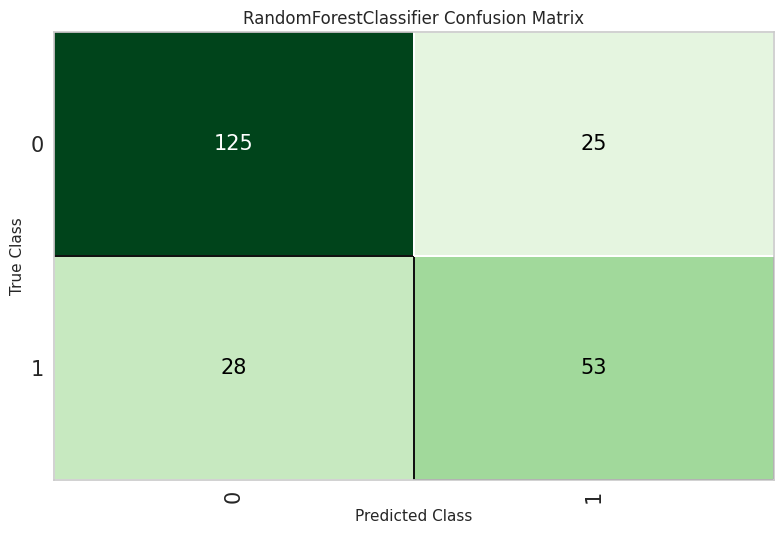

In [13]:
plot_model(best, plot='confusion_matrix')

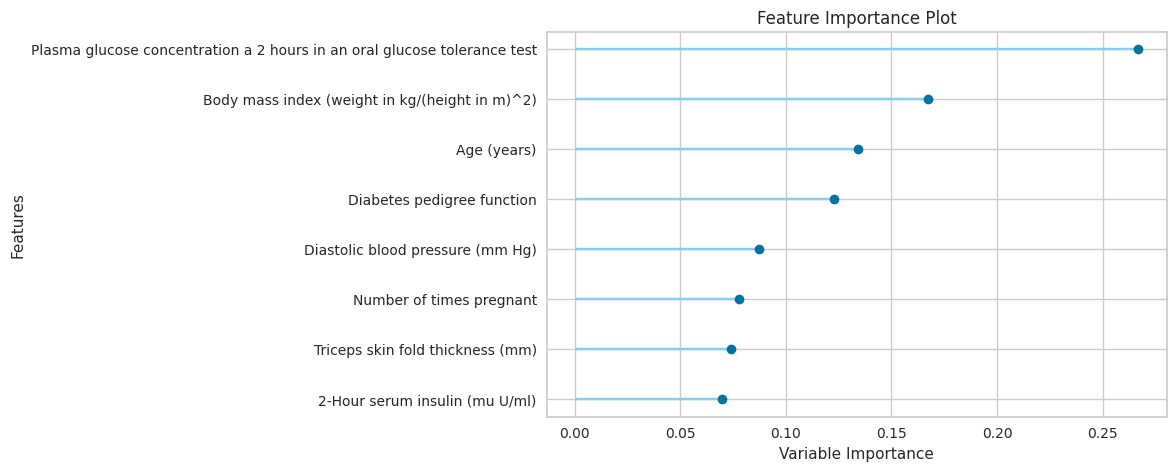

In [15]:
plot_model(best, plot='feature')

In [16]:
loaded_model_pipeline = load_model('diabetes_model')
loaded_model_pipeline

FileNotFoundError: [Errno 2] No such file or directory: 'diabetes_model.pkl'

In [ ]:
knn = create_model()